[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nrao/astrohack/blob/v0.9.4/docs/beamcut_tutorial.ipynb)

![astrohack](../_media/astrohack_logo.png)

# Beam cut analysis tutorial

Bla Bla

In [1]:
import os

try:
    import astrohack

    print("AstroHACK version", astrohack.__version__, "already installed.")
except ImportError as e:
    print(e)
    print("Installing AstroHACK")

    os.system("pip install astrohack")

    import astrohack

    print("astrohack version", astrohack.__version__, " installed.")

AstroHACK version 0.9.4 already installed.


## Download tutorial data

In [2]:
# Download data.
import toolviper

basename = "kband_beamcut_small"
ms_name = f"data/{basename}.ms"

toolviper.utils.data.update()
toolviper.utils.data.download(file=f"{basename}.ms", folder="data")

[2025-12-30 16:10:47,195]     INFO   astrohack:  Updating file metadata information ...  


Output()

[2025-12-30 16:10:47,699]     INFO   astrohack:  Module path: /home/victor/mambaforge/envs/casadev/lib/python3.12/site-packages/toolviper 
[2025-12-30 16:10:47,710]     INFO   astrohack:  Downloading from [cloudflare] .... 


 Download List           
 ──────────────────────── 
  kband_beamcut_small.ms

[2025-12-30 16:10:47,713]     INFO   astrohack:  Creating path:/home/victor/work/Holography-1022/astrohack/docs/data 


Output()

## Extract beam cut data to Astrohack formats

One has to use extract_pointing and extract_holog. Ignore missing data warning because it is a split dataset.

In [3]:
from astrohack import extract_pointing, extract_holog

point_name = f"data/{basename}.point.zarr"
holog_name = f"data/{basename}.holog.zarr"

# Extract pointing data to an astrohack file format
point_mds = extract_pointing(ms_name, point_name, overwrite=True)

# Extract visibilities to an astrohack file format
holog_mds = extract_holog(
    ms_name,
    point_name,
    holog_name,
    data_column="DATA",  # This applies to this dataset only as it has been split
    overwrite=True,
)

[2025-12-30 16:10:51,815]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 
[2025-12-30 16:10:55,477]     INFO   astrohack:  Finished processing 
[2025-12-30 16:10:55,552]     INFO   astrohack:  Processing ddi: 0, scans: [8 ... 13] 
[2025-12-30 16:11:03,219]     INFO   astrohack:  EA17: DDI 0: Suggested cell size 1.64 amin, FOV: (19.73 amin, 19.76 amin) 
[2025-12-30 16:11:03,221]     INFO   astrohack:  EA15: DDI 0: Suggested cell size 1.64 amin, FOV: (19.72 amin, 19.76 amin) 
[2025-12-30 16:11:04,565]     INFO   astrohack:  Finished extracting holography chunk for ddi: 0 holog_map_key: map_0 
[2025-12-30 16:11:04,566]     INFO   astrohack:  Processing ddi: 1, scans: [8 ... 13] 
[2025-12-30 16:11:04,887]     INFO   astrohack:  EA17: DDI 1: Suggested cell size 1.63 amin, FOV: (19.73 amin, 19.76 amin) 
[2025-12-30 16:11:04,889]     INFO   astrohack:  EA15: DDI 1: Suggested cell size 1.63 amin, FOV: (19.72 amin, 19.76 amin) 
[2025-12-30 16:11:04

## Running beamcut

No destination bla bla, destination bla bla

In [4]:
from astrohack import beamcut

beamcut_name = f"data/{basename}.beamcut.zarr"

beamcut_mds = beamcut(
    holog_name,
    beamcut_name,
    destination=None,  # This parameter is to be filled with a destination directory for beamcut products.
    overwrite=True,
)

[2025-12-30 16:11:05,111]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 
[2025-12-30 16:11:05,133]     INFO   astrohack:  processing EA17: DDI 1 
[2025-12-30 16:11:05,394]     INFO   astrohack:  processing EA17: DDI 0 
[2025-12-30 16:11:05,601]     INFO   astrohack:  processing EA15: DDI 1 
[2025-12-30 16:11:06,967]     INFO   astrohack:  processing EA15: DDI 0 
[2025-12-30 16:11:07,282]     INFO   astrohack:  Finished processing 


## Interact with beamcut file

In [5]:
from astrohack import open_beamcut

beamcut_mds = open_beamcut(beamcut_name)

beamcut_mds.summary()

####################################################################################################
###                                         Summary for:                                         ###
###                            data/kband_beamcut_small.beamcut.zarr                             ###
####################################################################################################

Full documentation for AstrohackBeamcutFile objects' API at: 
https://astrohack.readthedocs.io/en/stable/_api/autoapi/astrohack/mds/index.html#astrohack.mds.AstrohackBeamcutFile

Input Parameters:
+--------------+---------------------------------------+
| Parameter    | Value                                 |
+--------------+---------------------------------------+
| ant          | all                                   |
| azel_unit    | deg                                   |
| beamcut_name | data/kband_beamcut_small.beamcut.zarr |
| ddi          | all                                   |

### Observation summary

In [6]:
beamcut_mds.observation_summary("data/beamcut_summary.txt")

[2025-12-30 16:11:07,706]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 
############################################################
###                   ant_ea15, ddi_0                    ###
############################################################

   General:
      Telescope name     => EVLA
      Antenna name       => ea15
      Station            => N04
      Reference antennas => ['ea23 @ N08']
      Source             => HOLORASTER
      Phase center       => 16h42m58.810s +39°48m36.990s [FK5]
      Az el info         => @ l,m = (0,0), Az, El = (294.3, 45.4) [deg]
      Start time         => 25 Nov 2025, 23:10:56 (UTC)
      Stop time          => 25 Nov 2025, 23:20:42 (UTC)
      Duration           => 9 min, 46.05 sec

   Spectral:
      Channel width      => 2.000 MHz
      Frequency range    => 21.315 GHz to 21.443 GHz
      Number of channels => 64
      Rep. frequency     => 21.380 GHz
      Rep. wavelength    => 1.402 cm

### interacting with datatree

In [7]:
ea17_ddi_0 = beamcut_mds["ant_ea17"]["ddi_0"]

ea17_ddi_0

<xarray.DataTree 'ddi_0'>
Group: /ant_ea17/ddi_0
│   Attributes:
│       summary:  {'aperture': None, 'beam': {'cell size': 0.0004767736386022435,...
├── Group: /ant_ea17/ddi_0/cut_0
│       Dimensions:       (lm_dist: 487, time: 487, lm: 2)
│       Coordinates:
│         * lm_dist       (lm_dist) float64 4kB -0.002873 -0.002863 ... 0.002871
│         * time          (time) float64 4kB 5.271e+09 5.271e+09 ... 5.271e+09 5.271e+09
│       Dimensions without coordinates: lm
│       Data variables:
│           LL_amp_fit    (lm_dist) float64 4kB dask.array<chunksize=(487,), meta=np.ndarray>
│           LL_amplitude  (lm_dist) float64 4kB dask.array<chunksize=(487,), meta=np.ndarray>
│           LL_phase      (lm_dist) float64 4kB dask.array<chunksize=(487,), meta=np.ndarray>
│           LL_weight     (lm_dist) float64 4kB dask.array<chunksize=(487,), meta=np.ndarray>
│           RR_amp_fit    (lm_dist) float64 4kB dask.array<chunksize=(487,), meta=np.ndarray>
│           RR_amplitude  (lm_dist) float64 4kB dask.array<chunksize=(487,), meta=np.ndarray>
│           RR_phase      (lm_dist) float64 4kB dask.array<chunksize=(487,), meta=np.ndarray>
│           RR_weight     (lm_dist) float64 4kB dask.array<chunksize=(487,), meta=np.ndarray>
│           lm_offsets    (time, lm) float64 8kB dask.array<chunksize=(487, 2), meta=np.ndarray>
│       Attributes: (12/19)
│           LL_amp_fit_pars:           [-0.002077188719134862, 0.16536964764709944, 0...
│           LL_first_side_lobe_ratio:  0.9506970019203174
│           LL_fit_succeeded:          True
│           LL_n_peaks:                5
│           LL_pb_center:              2.0062998598862443e-05
│           LL_pb_fwhm:                0.000709009354625047
│           ...                        ...
│           available_corrs:           ['RR', 'LL']
│           direction:                 El. cut (S -> N)
│           lm_angle:                  8.043802534404685e-06
│           scan_number:               8
│           time_string:               2025-11-25 23:16
│           xlabel:                    Elevation offset
└── Group: /ant_ea17/ddi_0/cut_1
        Dimensions:       (lm_dist: 485, time: 485, lm: 2)
        Coordinates:
          * lm_dist       (lm_dist) float64 4kB 0.002271 0.002865 ... -0.00286 -0.002875
          * time          (time) float64 4kB 5.271e+09 5.271e+09 ... 5.271e+09 5.271e+09
        Dimensions without coordinates: lm
        Data variables:
            LL_amp_fit    (lm_dist) float64 4kB dask.array<chunksize=(485,), meta=np.ndarray>
            LL_amplitude  (lm_dist) float64 4kB dask.array<chunksize=(485,), meta=np.ndarray>
            LL_phase      (lm_dist) float64 4kB dask.array<chunksize=(485,), meta=np.ndarray>
            LL_weight     (lm_dist) float64 4kB dask.array<chunksize=(485,), meta=np.ndarray>
            RR_amp_fit    (lm_dist) float64 4kB dask.array<chunksize=(485,), meta=np.ndarray>
            RR_amplitude  (lm_dist) float64 4kB dask.array<chunksize=(485,), meta=np.ndarray>
            RR_phase      (lm_dist) float64 4kB dask.array<chunksize=(485,), meta=np.ndarray>
            RR_weight     (lm_dist) float64 4kB dask.array<chunksize=(485,), meta=np.ndarray>
            lm_offsets    (time, lm) float64 8kB dask.array<chunksize=(485, 2), meta=np.ndarray>
        Attributes: (12/19)
            LL_amp_fit_pars:           [-0.0021472318109970845, 0.07025296275717853, ...
            LL_first_side_lobe_ratio:  0.9386383160351017
            LL_fit_succeeded:          True
            LL_n_peaks:                5
            LL_pb_center:              7.307101442132769e-06
            LL_pb_fwhm:                0.0007120555281659058
            ...                        ...
            available_corrs:           ['RR', 'LL']
            direction:                 Az. cut (W -> E)
            lm_angle:                  1.5720178287317457
            scan_number:               13
            time_string:               2025-11-25 23:19
        

### Creating beam cut  plots
bla bla

#### Amplitude plots

[2025-12-30 16:11:08,064]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 


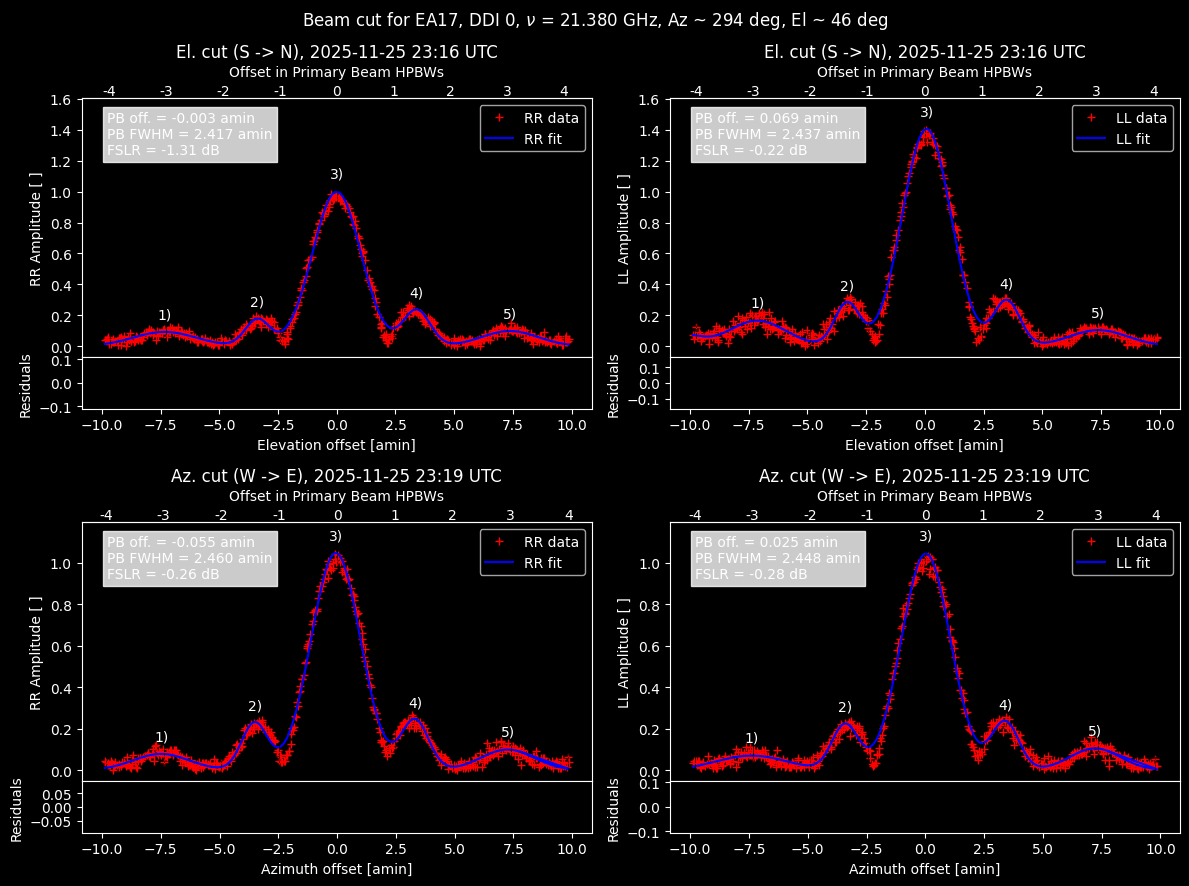

In [8]:
beamcut_exports = "beamcut_exports"

beamcut_mds.plot_beamcut_in_amplitude(
    beamcut_exports,
    ant="ea17",
    ddi=0,
    display=True,
)

#### Attenuation plots

[2025-12-30 16:11:11,228]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 


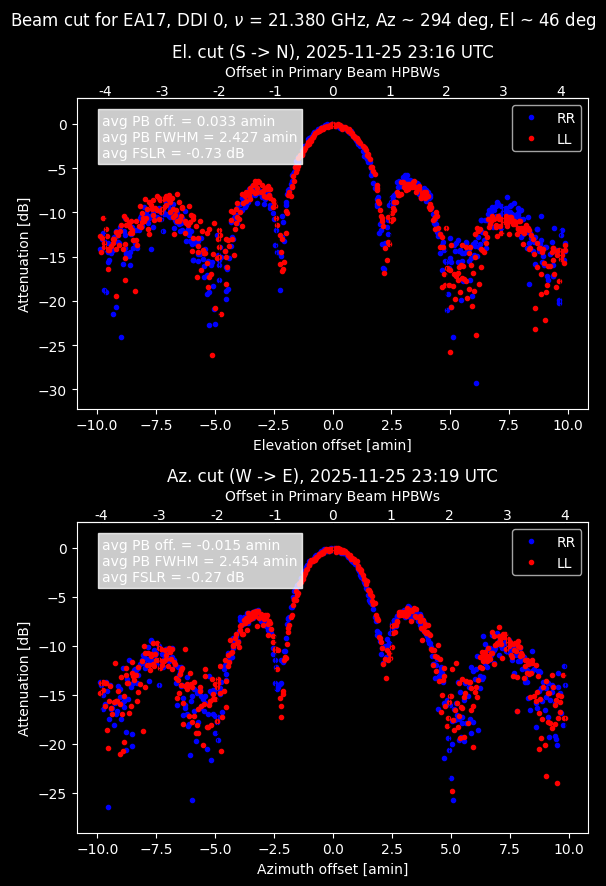

In [9]:
beamcut_mds.plot_beamcut_in_attenuation(
    beamcut_exports,
    ant="ea17",
    ddi=0,
    display=True,
)

#### Create report on beam cut gaussian fit

In [10]:
beamcut_mds.create_beam_fit_report(
    beamcut_exports,
    ant="ea17",
    ddi=0,
)

with open("beamcut_exports/beamcut_report_ant_ea17_ddi_0.txt", "r") as infile:
    for line in infile:
        print(line[:-1])

[2025-12-30 16:11:12,593]     INFO   astrohack:  Module path: /home/victor/work/Holography-1022/astrohack/src/astrohack 
- Beam cut for EA17, DDI 0, $\nu$ = 21.380 GHz, Az ~ 294 deg, El ~ 46 deg

  - RR El. cut (S -> N), 2025-11-25 23:16 UTC, Beam fit results:
    +----+---------------+---------------+-------------+------------------+
    | Id | Center [amin] | Amplitude [ ] | FWHM [amin] | Attenuation [dB] |
    +----+---------------+---------------+-------------+------------------+
    | 1) |     -7.328    |     0.092     |    3.118    |     -10.275      |
    | 2) |     -3.378    |     0.173     |    1.229    |      -7.546      |
    | 3) |     -0.003    |     0.999     |    2.417    |      0.066       |
    | 4) |     3.401     |     0.234     |    1.353    |      -6.239      |
    | 5) |     7.366     |     0.098     |    2.800    |     -10.011      |
    +----+---------------+---------------+-------------+------------------+

  - LL El. cut (S -> N), 2025-11-25 23:16 UTC, Beam fi